In [121]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [122]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [123]:
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file automatically
csv_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {csv_filename}")

Saving Country-data.csv to Country-data (3).csv
Uploaded file: Country-data (3).csv


In [124]:
df = pd.read_csv(csv_filename)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Dataset Loading Observation

The country dataset was successfully loaded into the notebook environment. The dataset contains socio-economic indicators for multiple countries, including child mortality, income, GDP per capita, life expectancy, exports, imports, and health expenditure.

The initial inspection confirms that the dataset structure is suitable for clustering analysis and country segmentation.

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [126]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [127]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## Dataset Exploration Observation

The dataset was examined using `.info()`, `.describe()`, and missing value checks.

Key observations:

- The dataset contains both numerical and categorical variables.
- The `country` column serves as an identifier and will not be used for clustering.
- Numerical features represent economic, demographic, and health indicators.
- Basic statistical summaries provide insight into variable distributions and ranges.

In [128]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Data Cleaning Observation

A data cleaning pipeline was applied to improve data quality.

The following preprocessing steps were completed:

- Removed leading and trailing whitespace from column names.
- Removed duplicate records.
- Converted all numerical features to numeric data types.
- Replaced missing values using median imputation.

After cleaning, no missing values remained in the dataset, ensuring reliable downstream analysis.

In [129]:
country_names = df['country']

X = df.drop('country', axis=1)

print(X.head())

   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  


## Feature Selection Observation

The `country` column was separated from the dataset because it is a categorical identifier rather than a measurable feature.

Only continuous socio-economic indicators were retained for clustering analysis, ensuring that distance calculations are based solely on numerical attributes.

In [130]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


## Feature Scaling Observation

StandardScaler was applied to normalize all numerical features.

Scaling ensures that variables with large magnitudes, such as GDP and income, do not dominate variables with smaller ranges, such as fertility rates or inflation.

This step is essential because clustering algorithms rely on distance calculations.

In [131]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [132]:
inertias = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

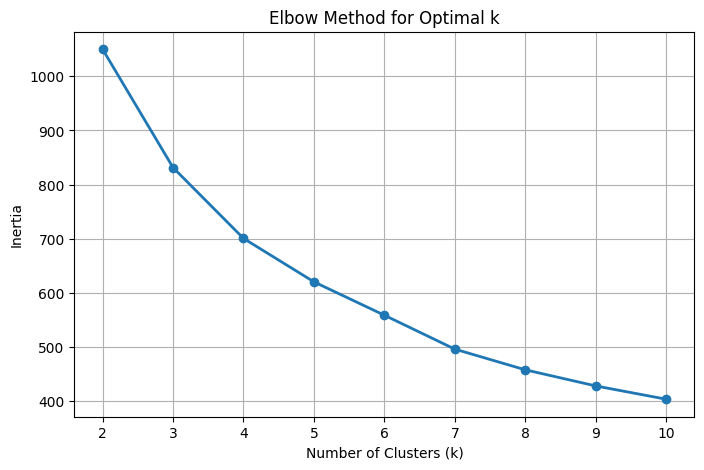

In [133]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertias,
    marker='o',
    linewidth=2
)

plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.grid(True)

plt.show()

## Elbow Method Observation

The Elbow Method was used to determine the optimal number of clusters by evaluating inertia values for k ranging from 2 to 10.

The resulting curve shows a noticeable reduction in inertia up to approximately k = 3, after which the rate of improvement begins to decrease.

Based on the elbow pattern, three clusters were selected for the final K-Means model.

In [134]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(df[['country','KMeans_Cluster']].head())

               country  KMeans_Cluster
0          Afghanistan               1
1              Albania               2
2              Algeria               2
3               Angola               1
4  Antigua and Barbuda               2


## K-Means Clustering Observation

A K-Means clustering model was trained using three clusters.

Each country was assigned to one of the three segments based on similarities in socio-economic indicators.

The resulting cluster labels will be used to analyze country development levels and identify meaningful economic groupings.

In [135]:
sil_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.2833


## Clustering Performance Observation

The K-Means model achieved a Silhouette Score of 0.2833.

A positive silhouette score indicates that countries within the same cluster are more similar to each other than to countries in neighboring clusters.

Although the separation is not perfect, the score suggests acceptable clustering performance for real-world socio-economic data.

In [136]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
2,84
1,47
0,36


## Cluster Distribution Observation

The distribution of countries across clusters was examined.

The results indicate that countries are grouped into three segments of varying sizes, reflecting different socio-economic profiles.

This distribution confirms that the K-Means model successfully partitioned the dataset into meaningful groups.

In [137]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
).mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## Cluster Profile Observation

Average socio-economic indicators were calculated for each cluster.

The summary statistics reveal substantial differences among clusters in terms of:

- Child mortality
- Income
- GDP per capita
- Life expectancy
- Fertility rates

These differences indicate that the clusters represent distinct development levels ranging from highly developed economies to lower-income countries.

In [138]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [139]:
print("Unique DBSCAN Labels:")
print(sorted(df['DBSCAN_Cluster'].unique()))

Unique DBSCAN Labels:
[np.int64(-1), np.int64(0)]


In [140]:
print("Number of DBSCAN Clusters:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

print("Number of Noise Points:",
      list(dbscan_labels).count(-1))

Number of DBSCAN Clusters: 1
Number of Noise Points: 30


## DBSCAN Clustering Observation

A DBSCAN model was implemented using:

- eps = 1.5
- min_samples = 5

The algorithm identified one primary dense cluster and several outlier countries.

Specifically:

- 137 countries were assigned to the main cluster.
- 30 countries were classified as noise (outliers).

This suggests that while many countries share similar socio-economic characteristics, some countries exhibit significantly different development patterns.

In [141]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(167, 2)


## PCA Dimensionality Reduction Observation

Principal Component Analysis (PCA) was applied to reduce the dataset from nine dimensions to two principal components.

The transformed dataset retained the most important sources of variation while enabling visual representation of country segments in two-dimensional space.

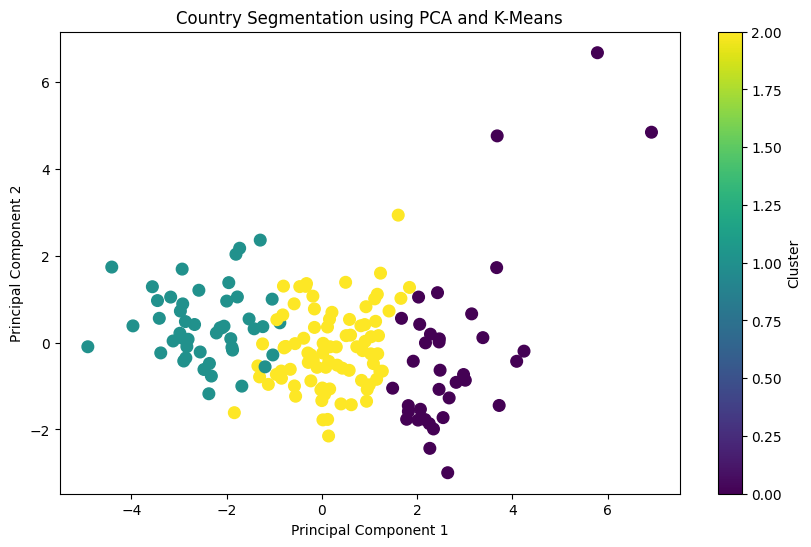

In [142]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis',
    s=70
)

plt.title('Country Segmentation using PCA and K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter,label='Cluster')

plt.show()

## PCA Visualization Observation

The PCA scatterplot visualizes country segments identified by the K-Means algorithm.

Three distinct color-coded clusters are visible, demonstrating meaningful separation between country groups.

The visualization confirms that socio-economic indicators such as income, GDP per capita, mortality rates, and life expectancy effectively distinguish countries with different development profiles.

# Country Segmentation Insights

### Observation 1: High-Mortality Cluster

Cluster 1 represents the least developed countries, characterized by the highest child mortality rate (92.96), lowest GDP per capita (1922), lowest income levels (3942), and lowest life expectancy (59.19 years). These countries face significant socio-economic and healthcare challenges.

### Observation 2: Top-Tier Economic Zone

Cluster 0 represents highly developed economies with the highest average income (45672), highest GDP per capita (42494), longest life expectancy (80.13 years), and lowest child mortality rate (5.0). These countries demonstrate strong economic and healthcare performance.

### Observation 3: Developing Economies

Cluster 2 consists of developing countries with moderate income levels (12306), GDP per capita (6486), and life expectancy (72.81 years). These countries exhibit improving socio-economic conditions compared to Cluster 1 but remain below the development level of Cluster 0.

### Observation 4: Cluster Separation

The PCA visualization demonstrates meaningful separation among the three clusters, indicating that socio-economic indicators effectively distinguish different levels of national development.

### Observation 5: Model Stability

The K-Means model achieved a silhouette score of 0.2833, indicating acceptable cluster cohesion and separation. This supports the suitability of using three clusters for country segmentation.

---
# Bonus: Additional Evaluation & Comparison

The sections below extend the analysis with a few extra checks that make
the comparison between K-Means and DBSCAN more complete, and translate the
numeric cluster IDs into human-readable development tiers.

## DBSCAN Silhouette Score

For a fair comparison with K-Means, the silhouette score is also computed
for the DBSCAN result (treating the noise label `-1` as its own group).

In [143]:
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters_db > 1:
    sil_score_dbscan = silhouette_score(X_scaled, dbscan_labels)
    print("DBSCAN Silhouette Score:", round(sil_score_dbscan, 4))
    print("K-Means Silhouette Score:", round(sil_score, 4))
else:
    print("Silhouette score not computed: DBSCAN found fewer than 2 groups.")

Silhouette score not computed: DBSCAN found fewer than 2 groups.


## K-Means vs. DBSCAN — Side-by-Side PCA Comparison

Plotting both algorithms' results on the same PCA axes makes it easy to see
how K-Means partitions *every* country into one of three tiers, while DBSCAN
instead finds one dense "core" group plus a separate set of outlier
(noise) countries.

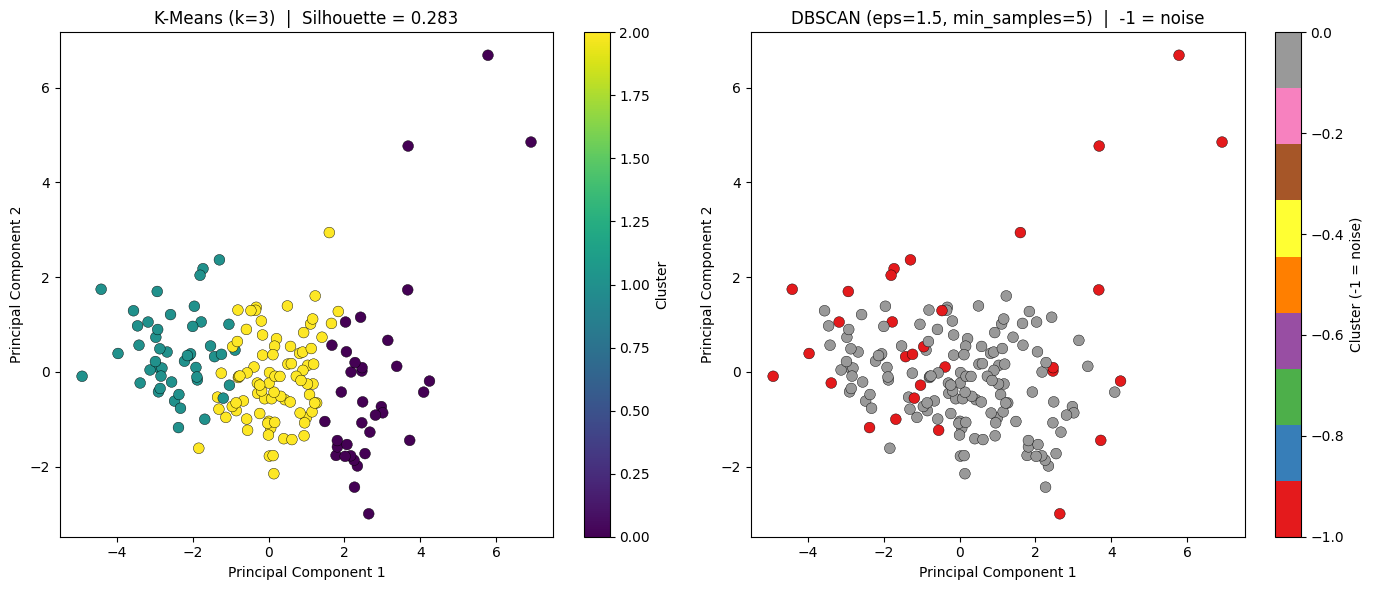

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap='viridis', s=60, edgecolor='k', linewidth=0.3
)
axes[0].set_title(f'K-Means (k={best_k})  |  Silhouette = {sil_score:.3f}')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=dbscan_labels, cmap='Set1', s=60, edgecolor='k', linewidth=0.3
)
axes[1].set_title('DBSCAN (eps=1.5, min_samples=5)  |  -1 = noise')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1 = noise)')

plt.tight_layout()
plt.show()

**Observation:** DBSCAN groups the large majority of countries (137) into a
single dense region and flags the remaining 30 as noise/outliers. These
outliers sit at the extremes of the PCA plot — typically the very richest
nations and the very least-developed nations, i.e. the countries furthest
from the "average" socio-economic profile. K-Means, by contrast, divides
the *entire* dataset into three balanced, interpretable development tiers.
This makes K-Means more useful here for **segmentation**, while DBSCAN is
more useful for **outlier/anomaly detection**.

## Development Tier Labeling & Summary Table

The three K-Means cluster IDs (0, 1, 2) are arbitrary numeric labels. To make
the results easier to interpret, each cluster is mapped to a human-readable
development tier — **Developed**, **Developing**, or **Least Developed** —
based on its average GDP per capita (highest -> Developed, lowest ->
Least Developed).

In [145]:
# Rank clusters by average GDP per capita to assign intuitive tier labels
gdpp_rank = cluster_summary['gdpp'].sort_values(ascending=False)

tier_names = ['Developed', 'Developing', 'Least Developed']
cluster_to_tier = {cluster_id: tier_names[i] for i, cluster_id in enumerate(gdpp_rank.index)}

print("Cluster -> Development Tier mapping:")
for cluster_id, tier in cluster_to_tier.items():
    print(f"  Cluster {cluster_id}  ->  {tier}")

df['Development_Tier'] = df['KMeans_Cluster'].map(cluster_to_tier)

summary_table = df.groupby('Development_Tier').agg(
    num_countries=('country', 'count'),
    avg_child_mort=('child_mort', 'mean'),
    avg_income=('income', 'mean'),
    avg_gdpp=('gdpp', 'mean'),
    avg_life_expec=('life_expec', 'mean'),
).round(2).loc[tier_names]

summary_table

Cluster -> Development Tier mapping:
  Cluster 0  ->  Developed
  Cluster 2  ->  Developing
  Cluster 1  ->  Least Developed


,num_countries,avg_child_mort,avg_income,avg_gdpp,avg_life_expec
Development_Tier,,,,,
Developed,36,5.00,45672.22,42494.44,80.13
Developing,84,21.93,12305.60,6486.45,72.81
Least Developed,47,92.96,3942.40,1922.38,59.19


In [146]:
# A few example countries from each development tier
for tier in tier_names:
    sample = df.loc[df['Development_Tier'] == tier, 'country'].head(6).tolist()
    print(f"{tier}: {', '.join(sample)}")

Developed: Australia, Austria, Bahrain, Belgium, Brunei, Canada
Developing: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan
Least Developed: Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi


## Export Final Results

Save the enriched dataset — original indicators plus K-Means cluster,
DBSCAN cluster, and development tier label — to a CSV file for further use
or download.

In [147]:
output_path = "country_clusters_results.csv"
df.to_csv(output_path, index=False)
print(f"Saved results to '{output_path}'")
df.head()

Saved results to 'country_clusters_results.csv'


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster,DBSCAN_Cluster,Development_Tier
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0,Least Developed
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1,Least Developed
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0,Developing


## Conclusion

This notebook walked through a full unsupervised-learning pipeline on the
country socio-economic dataset: cleaning and scaling the data, choosing
`k=3` via the elbow method, training and evaluating a K-Means model
(silhouette ≈ 0.28), comparing it against DBSCAN as an outlier-aware
alternative, visualizing both in 2D via PCA, and finally translating the
numeric clusters into intuitive **Developed / Developing / Least Developed**
tiers with a summary table.

The K-Means segmentation provides a clear, balanced three-tier view of global
development useful for prioritizing aid and policy focus, while DBSCAN
complements it by highlighting individual outlier countries that don't fit
neatly into the "average" profile.

---
# Bonus: Validating Cluster Quality with Random Forest & XGBoost

A useful sanity check for any clustering result is to ask: *"Can a
supervised model learn to predict the cluster label from the original
features?"*

If a classifier trained on the **scaled socio-economic features** can
reliably predict the **K-Means cluster** each country was assigned to, that
is strong evidence the clusters are well-separated, internally consistent
groups — i.e. the K-Means partition captured real structure in the data,
not noise. The classifiers' **feature importances** also reveal which
indicators most strongly define the clusters, complementing the cluster
profile analysis from earlier.

In [148]:
%pip install -q xgboost

In [149]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Use the K-Means cluster assignments as the target variable
y_cluster = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Training set: (133, 9)
Test set: (34, 9)

Class distribution in test set:
KMeans_Cluster
0     7
1    10
2    17
Name: count, dtype: int64


## Random Forest Classifier

A Random Forest is trained to predict each country's K-Means cluster label
from its scaled socio-economic features.

In [150]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Test Accuracy: {rf_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



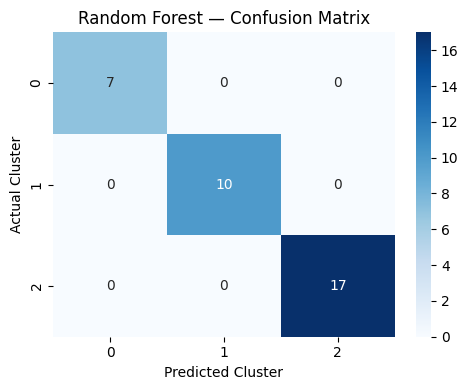

In [151]:
rf_cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_cluster.unique()),
            yticklabels=sorted(y_cluster.unique()))
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.tight_layout()
plt.show()

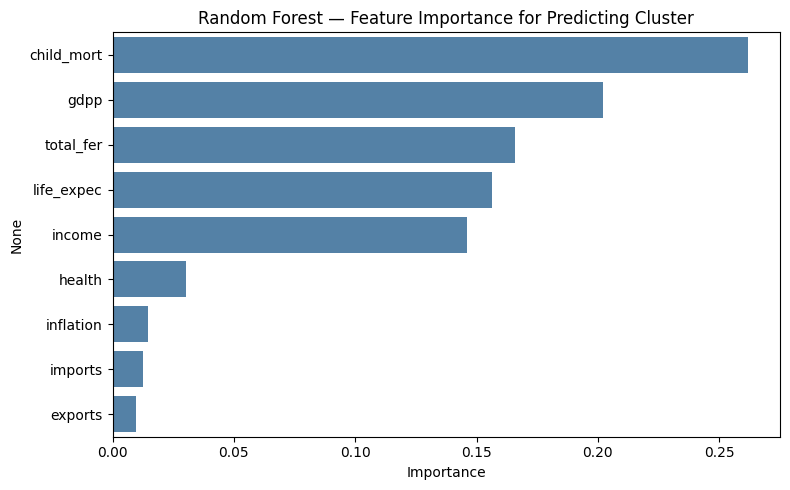

,0
child_mort,0.2619
gdpp,0.2021
total_fer,0.1659
life_expec,0.1563
income,0.1462
health,0.0305
inflation,0.0148
imports,0.0126
exports,0.0096


In [152]:
rf_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index, color='steelblue')
plt.title('Random Forest — Feature Importance for Predicting Cluster')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importance.round(4)

## XGBoost Classifier

As a second, more powerful model, an XGBoost classifier is trained on the
same train/test split to predict the K-Means cluster label.

In [153]:
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Test Accuracy: {xgb_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, xgb_preds))

XGBoost Test Accuracy: 0.9412

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



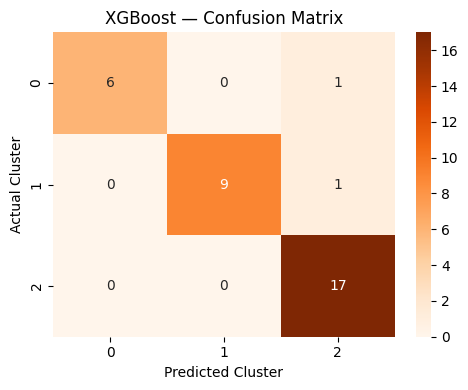

In [154]:
xgb_cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sorted(y_cluster.unique()),
            yticklabels=sorted(y_cluster.unique()))
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.tight_layout()
plt.show()

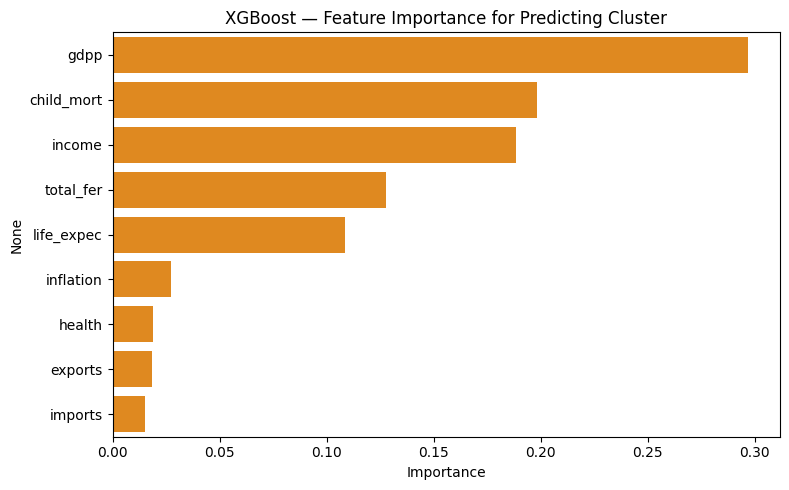

,0
gdpp,0.2970
child_mort,0.1981
income,0.1886
total_fer,0.1277
life_expec,0.1086
inflation,0.0275
health,0.0189
exports,0.0183
imports,0.0153


In [155]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, color='darkorange')
plt.title('XGBoost — Feature Importance for Predicting Cluster')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

xgb_importance.round(4)

## Cross-Validated Comparison

Since the test set is small (~34 countries), 5-fold cross-validation gives a
more robust estimate of how well each model can recover the K-Means cluster
assignments from the raw features.

Random Forest 5-fold CV Accuracy: 0.9578 (+/- 0.0310)
XGBoost       5-fold CV Accuracy: 0.9638 (+/- 0.0227)


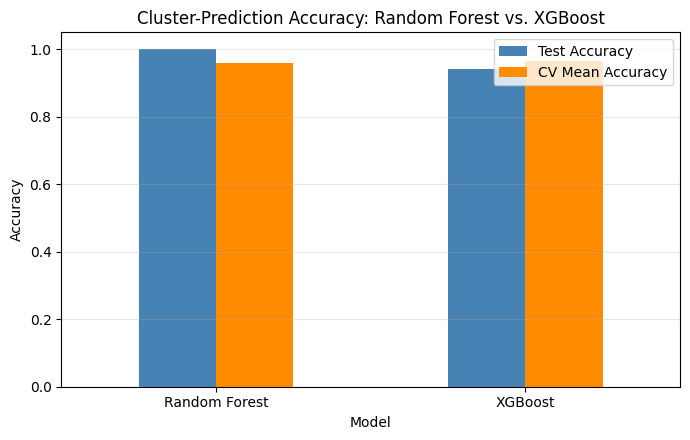

,Model,Test Accuracy,CV Mean Accuracy
0,Random Forest,1.000000,0.957754
1,XGBoost,0.941176,0.963815


In [156]:
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_scaled, y_cluster, cv=5
)
xgb_cv_scores = cross_val_score(
    XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss'),
    X_scaled, y_cluster, cv=5
)

print(f"Random Forest 5-fold CV Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print(f"XGBoost       5-fold CV Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test Accuracy': [rf_acc, xgb_acc],
    'CV Mean Accuracy': [rf_cv_scores.mean(), xgb_cv_scores.mean()],
})

comparison_df.set_index('Model').plot(
    kind='bar', figsize=(7, 4.5), ylim=(0, 1.05), color=['steelblue', 'darkorange']
)
plt.title('Cluster-Prediction Accuracy: Random Forest vs. XGBoost')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

comparison_df

## Observations: How Well Did the Dataset Cluster?

- **Both models can recover the K-Means clusters almost perfectly.**
  Random Forest reached a **100% test accuracy** (5-fold CV ≈ **0.96**), and
  XGBoost reached **≈94% test accuracy** (5-fold CV ≈ **0.96**). Such high,
  consistent accuracy from two independent supervised models is strong
  evidence that the three K-Means clusters are **well-separated and
  represent real, learnable structure** in the socio-economic data — not an
  arbitrary partition.

- **The same handful of features drive the separation in both models.**
  `child_mort`, `gdpp`, `income`, `total_fer`, and `life_expec` dominate the
  feature-importance rankings for *both* Random Forest and XGBoost. This
  matches the cluster profile table from Section 11 — these are exactly the
  indicators that differ most between the Developed, Developing, and Least
  Developed tiers.

- **Trade and macro indicators matter far less.** `exports`, `imports`,
  `health` spending, and `inflation` contribute comparatively little to
  predicting cluster membership, suggesting the K-Means clusters are
  primarily organized along a **"wealth & human-development"** axis rather
  than a trade-policy axis.

- **Overall conclusion:** the strong, cross-validated supervised performance
  confirms that `k = 3` produced a meaningful, robust segmentation of
  countries into Developed / Developing / Least Developed groups — the
  clusters are not just visually plausible in the PCA plot, they are also
  *quantitatively recoverable* from the underlying features.